In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models('vllm') + ['siglip2_so400_16_256']
# models = ['siglip_so400_14', 'siglip_so400_14_384', 'siglip_so400_14_378', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)
results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("num_classes")
results["num_classes"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification') | (results['model_name'].str.contains('SigLIP')) | (results['task_name'] == 'multi_choice_relation')]

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

/tmp/ipykernel_3034745/2614091269.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3034745/2614091269.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3034745/2614091269.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3034745/2614091269.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3034745/2614091269.py:39: Fut

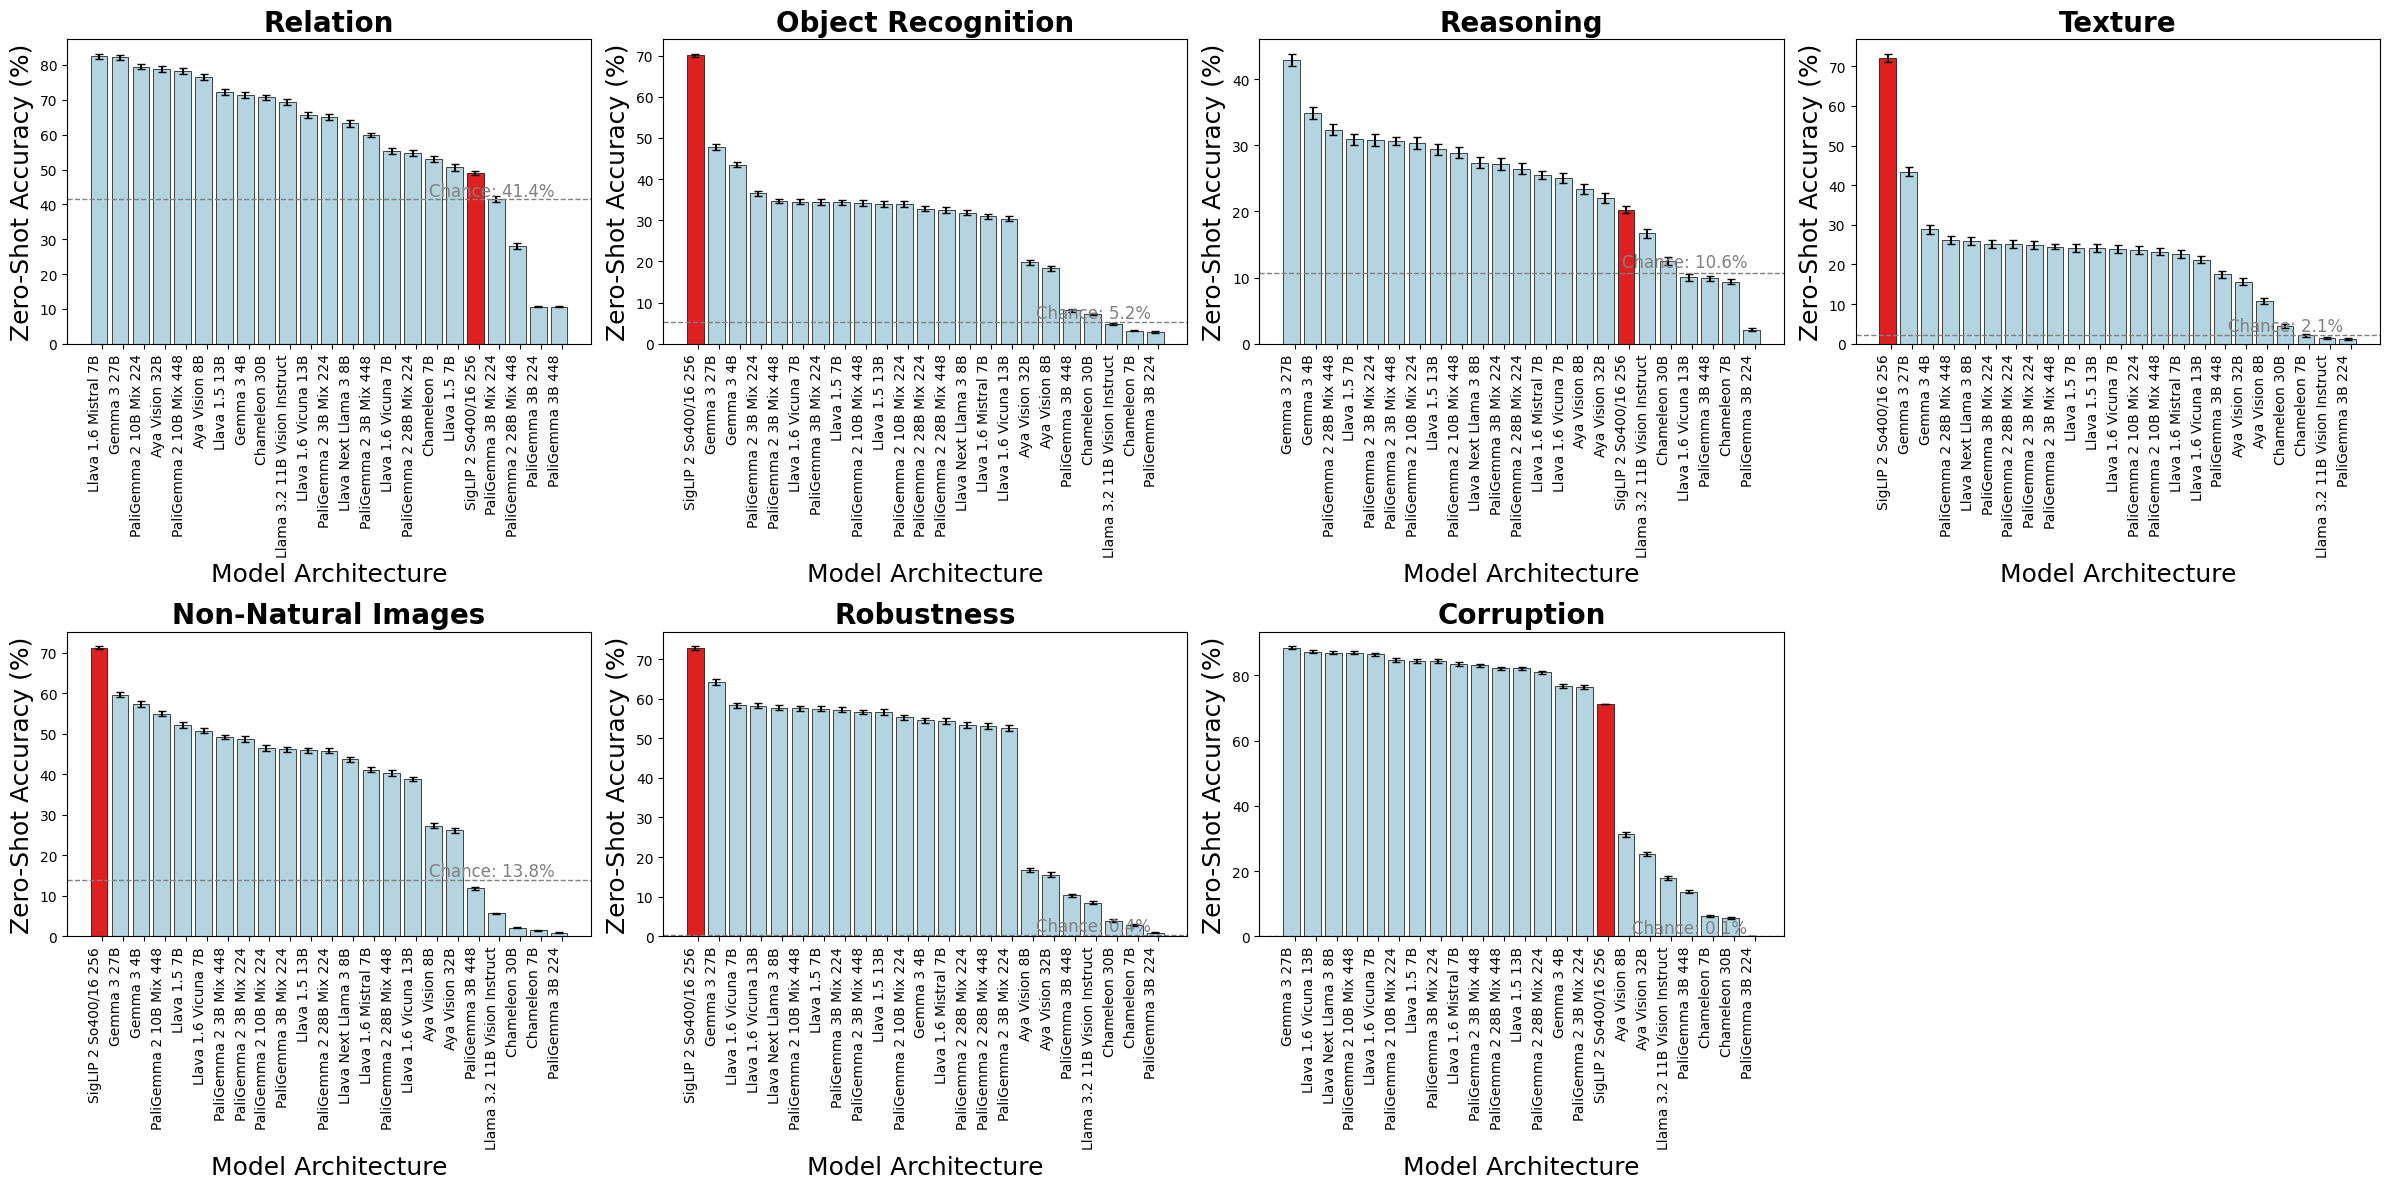

In [4]:
# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Get unique benchmark types
benchmark_types = results['benchmark_type'].unique()

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, bench_type in enumerate(benchmark_types):
    # Filter data for this benchmark type
    type_results = results[results['benchmark_type'] == bench_type]
    
    # Compute average and SEM for this benchmark type
    df_mean_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.mean()
    df_sem_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.sem()
    
    type_performance = df_mean_type.reset_index().groupby("model_name").correctness.mean() * 100
    type_sem = df_sem_type.reset_index().groupby("model_name").correctness.mean() * 100
    
    type_model_data = pd.DataFrame({
        'model_name': type_performance.index,
        'performance': type_performance.values,
        'sem': type_sem.values
    })
    
    # Sort by performance
    sorted_type_models = type_model_data.sort_values('performance', ascending=False)
    
    # Create colors: red for SigLIP, light blue for others
    colors = ['red' if 'SigLIP' in name else 'lightblue' for name in sorted_type_models['model_name']]
    
    # Create barplot for this subplot
    ax = axes[i]
    sns.barplot(
        data=sorted_type_models,
        x='model_name',
        y='performance',
        palette=colors,
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    
    # Add error bars
    for j, row in enumerate(sorted_type_models.itertuples()):
        ax.errorbar(j, row.performance, yerr=row.sem, fmt='none', color='black',
                   capsize=3, elinewidth=1.5)
    
    # Customize this subplot
    ax.set_xlabel('Model Architecture', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=LABEL_FONT_SIZE)
    ax.set_title(f'{bench_type.title()}', fontsize=TITLE_FONT_SIZE, weight='bold')
    
    # Format x-axis labels
    tick_positions = [i + 0.15 for i in range(len(sorted_type_models))]
    ax.set_xticks(tick_positions)
    tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_type_models['model_name']]
    ax.set_xticklabels(tick_labels, rotation=90, ha='right')
    
    # Calculate chance level for this benchmark type
    benchmarks_in_type = type_results['benchmark_name'].unique()
    chance_levels = []
    for benchmark in benchmarks_in_type:
        num_classes = benchmark_mappings.get(benchmark, 2)  # Default to 2 if not found
        chance_level = (1.0 / num_classes) * 100
        chance_levels.append(chance_level)
    
    # Use average chance level across benchmarks in this type
    avg_chance_level = sum(chance_levels) / len(chance_levels)
    
    # Add chance level line
    ax.axhline(avg_chance_level, linestyle='--', color='gray', linewidth=1)
    ax.text(len(sorted_type_models) - 1.2, avg_chance_level + 1,
            f'Chance: {avg_chance_level:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
            color='gray', ha='right')

# Hide any unused subplots
for i in range(len(benchmark_types), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


In [2]:
import os
import glob
import pandas as pd

# Get all CSV files in the directory
csv_files = glob.glob('/home/haltahan6/unibench/figures/validation_results/*.csv')

# Read and concatenate all CSV files
validation_dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    validation_dfs.append(df)

# Merge all dataframes into one
validation_results = pd.concat(validation_dfs, ignore_index=True)

print(f"Loaded {len(csv_files)} CSV files")
print(f"Combined dataframe shape: {validation_results.shape}")
print(validation_results.head())

Loaded 6 CSV files
Combined dataframe shape: (1387455, 6)
                                              prompt  \
0  <|begin_of_text|><|start_header_id|>user<|end_...   
1  <|begin_of_text|><|start_header_id|>user<|end_...   
2  <|begin_of_text|><|start_header_id|>user<|end_...   
3  <|begin_of_text|><|start_header_id|>user<|end_...   
4  <|begin_of_text|><|start_header_id|>user<|end_...   

                                        model_output output_valid  \
0  The object in this photo is a person wearing a...         True   
1  The object in the photo is a pagoda, which is ...         True   
2               The object in the photo is a camera.         True   
3           The object in the photo is a motorcycle.         True   
4     The object in the photo is a pair of scissors.         True   

                      model_name benchmark_name                    task_name  
0  Llama 3.2 11B Vision Instruct     caltech101  multi_choice_classification  
1  Llama 3.2 11B Vision Instruct

In [8]:
# Handle NaN values first, then convert output_valid from string to boolean, then to numeric
validation_results['output_valid'] = validation_results['output_valid'].fillna('False').astype(str)
validation_results['output_valid'] = validation_results['output_valid'].map({'True': 1, 'False': 0, 'true': 1, 'false': 0})
validation_results['output_valid'] = validation_results['output_valid'].fillna(0).astype(int)

/tmp/ipykernel_3241073/1458562053.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


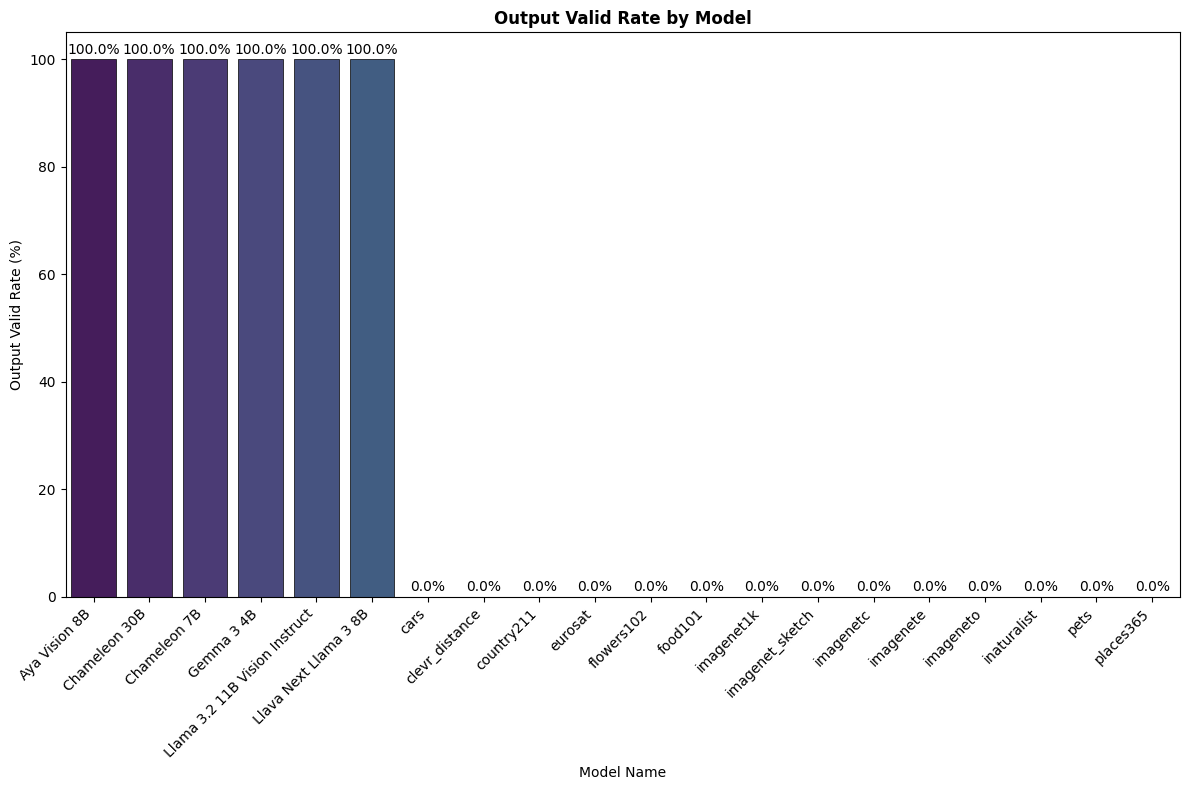

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate output_valid performance for each model
model_performance = validation_results.groupby('model_name')['output_valid'].mean() * 100

# Create a DataFrame for plotting
performance_df = pd.DataFrame({
    'model_name': model_performance.index,
    'output_valid_rate': model_performance.values
}).sort_values('output_valid_rate', ascending=False)

# Create the barplot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=performance_df,
    x='model_name',
    y='output_valid_rate',
    palette='viridis',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Output Valid Rate by Model', weight='bold')
plt.xlabel('Model Name')
plt.ylabel('Output Valid Rate (%)')
plt.xticks(rotation=45, ha='right')


# Add value labels on top of bars
for i, v in enumerate(performance_df['output_valid_rate']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()